# Analyse Time in EuXFEL switchyard

In [1]:
import os
os.chdir('/Users/marindeniaud/PhD/PhD-git/luxe-backgrounds/06_analysis/')

import numpy as _np
import matplotlib.pyplot as _plt
import pymad8 as _m8

import XFEL_BPM
import loadXFELdata
import plotXFELdata

initializing ocelot...


### Date and save prefix

In [2]:
date = "2026_06_02"
save_name_prefix = "jupyter_notebooks/plots/EUXFEL/Energy/" + date + "_EuXFEL_plot"

### Load file

In [3]:
file = 'XFEL_data/ArrivalTime_data/matched_linac_main_run2148_file109482_20231119T155947.all.hdf5'
file = 'XFEL_data/BPM_data/matched_linac_main_run2148_file114155_20231120T155943.all.hdf5'

In [4]:
BPMData = loadXFELdata.XFELdata(file, getPosition=False, getCharge=False, getEnergy=True, getTime=False)

Loaded file 'matched_linac_main_run2148_file114155_20231120T155943.all.hdf5'
Loading 49 bpms, 3391 trains and 2708 bunches in df: |██████████████████████████████████████████████████| 100.0% Complete


## Plot

In [5]:
def plotOneHist(ax, df_reduced, coord='X', label="x", unit=r"$\rm \mu m$", minCut=None, maxCut=None, nbins=50):
    X_cut = df_reduced[coord][minCut:maxCut]
    ax.hist(X_cut, bins=nbins, histtype='step', color='C0',
            label=r"$\sigma_{{s,{}}}$ = {:.2f} {}".format(label, _np.std(X_cut* 1e3), 'MeV'))
    ax.set_ylabel("counts")
    ax.set_xlabel("{} [{}]".format(label, unit))
    ax.legend()

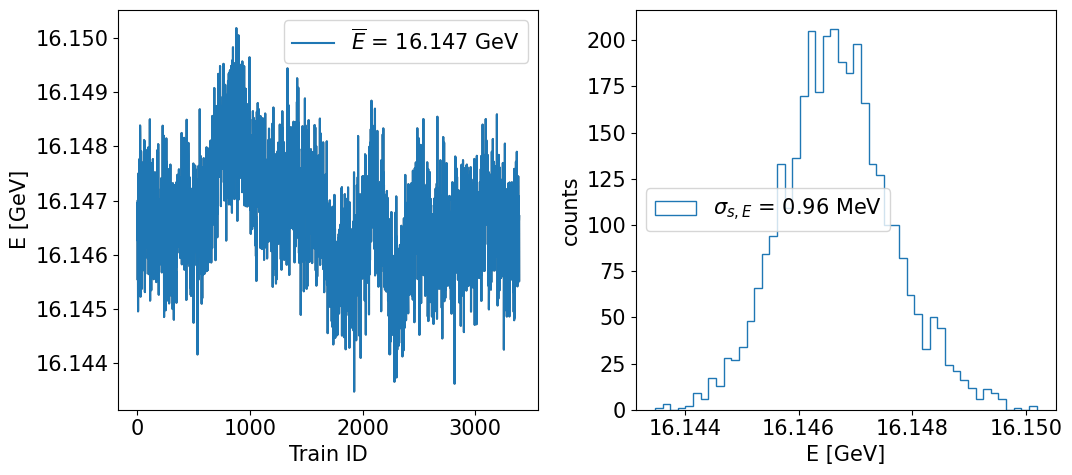

In [6]:
import matplotlib.ticker as mtick
minCut=None
maxCut=None
df_reduced = BPMData.reduceDFbyBPMTrainBunchByIndex(bpms="BPMA.1873.TL", trains=None, bunches=91)
xlabel = 'Train ID'
slist = df_reduced.index.get_level_values('TrainID')
slist -= slist[0]

fig = _plt.figure(figsize=[11, 5])
gs = fig.add_gridspec(1, 2)
ax_left = fig.add_subplot(gs[0, 0])
ax_left.yaxis.set_major_formatter(mtick.ScalarFormatter(useOffset=False))
ax_right = fig.add_subplot(gs[0, 1])
ax_right.xaxis.set_major_formatter(mtick.ScalarFormatter(useOffset=False))

plotXFELdata.plotOneAlong(ax_left, df_reduced, slist, xlabel, coord='E', label="E", unit='GeV', minCut=minCut, maxCut=maxCut)
plotOneHist(ax_right, df_reduced, coord='E', label="E", unit='GeV', minCut=minCut, maxCut=maxCut)
_plt.tight_layout()
_plt.savefig("{}_Energy_per_train.pdf".format(save_name_prefix), dpi=300, bbox_inches='tight')

In [46]:
E0 = 16100 #MeV
Dx = 0.4 #m
x = 20e-6 #m
err_x = 10e-6 #m

_np.sqrt((Dx-x)/Dx**2) * err_x

np.float64(1.5811388300841898e-05)